# Notebook 05 — Análisis Estadístico de Significancia
Objetivo: Cuantificar estadísticamente qué variables discriminan entre grupos de resultado, medir el tamaño del efecto, y construir la Tabla Maestra de Features que alimentará directamente los modelos del NB06.
Este notebook replantea el NB05 original incorporando hallazgos ya disponibles de NB01–NB04 y evitando re-ejecutar análisis ya completados. El foco está en profundizar la caracterización estadística y producir la Tabla Maestra de Features con evidencia cuantitativa.
Preparación del Entorno y Carga de Datos
En esta sección, cargamos el dataset y definimos los subconjuntos clave basados en los hallazgos de NB01:

df_all: Todos los 764 registros.
df_activos: 554 estudiantes con estado 'APROBÓ' o 'REPROBÓ' (excluye retirados y sin nota).
df_activos_engagement: 502 estudiantes activos con engagement >0 (excluye los 52 sin engagement, principalmente del formato antiguo).

Justificación: Estos subconjuntos aseguran que los análisis se centren en datos válidos y relevantes, evitando sesgos por retiros tempranos o falta de datos.
Python

In [20]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, kruskal
import pingouin as pg  # Para mwu con rank-biserial y correlaciones parciales
from sklearn.metrics import roc_auc_score, cohen_kappa_score  # AUC y Cohen's d (usamos pingouin para d)
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Cargar el dataset
df_all = pd.read_csv('../data/dataset_completo_final.csv')

# Definir subconjuntos
df_activos = df_all[df_all['estado'].isin(['APROBÓ', 'REPROBÓ'])].copy()  # N=554
df_activos_engagement = df_activos[df_activos['engagement_hasta_p1'] > 0].copy()  # N=502, excluye sin engagement

# Crear variable binaria para target: 1=REPROBÓ, 0=APROBÓ
df_activos['estado_binario'] = (df_activos['estado'] == 'REPROBÓ').astype(int)
df_activos_engagement['estado_binario'] = (df_activos_engagement['estado'] == 'REPROBÓ').astype(int)

# Grupos para tests
aprobados = df_activos[df_activos['estado'] == 'APROBÓ']
reprobados = df_activos[df_activos['estado'] == 'REPROBÓ']
aprobados_eng = df_activos_engagement[df_activos_engagement['estado'] == 'APROBÓ']
reprobados_eng = df_activos_engagement[df_activos_engagement['estado'] == 'REPROBÓ']

# Codificar 'era' como binario: 0=antiguo, 1=nuevo
df_activos['era_encoded'] = (df_activos['era'] == 'formato_nuevo').astype(int)
df_activos_engagement['era_encoded'] = (df_activos_engagement['era'] == 'formato_nuevo').astype(int)

print(f"Dimensiones: df_all={df_all.shape}, df_activos={df_activos.shape}, df_activos_engagement={df_activos_engagement.shape}")

Dimensiones: df_all=(764, 77), df_activos=(554, 79), df_activos_engagement=(502, 79)


# Sección 5.1 — Marco Estadístico y Decisiones de Diseño
Esta sección justifica las decisiones metodológicas que guían todo el notebook.
## 5.1.1 Justificación de tests no-paramétricos
Las distribuciones de notas y engagement no son normales en todos los grupos (especialmente los REPROBÓ con scores concentrados en el extremo inferior), como se identificó en NB03. Por esta razón, el análisis privilegia:

Mann-Whitney U (en lugar de t-test) para comparaciones binarias APROBÓ vs. REPROBÓ.
Kruskal-Wallis (en lugar de ANOVA) para comparaciones entre semestres.
Correlación de Spearman (en lugar de Pearson) como medida de asociación robusta.

Cuando los grupos son suficientemente grandes (N>30) y la distribución es aproximadamente simétrica, se reporta también Cohen's d para facilitar la comparación con literatura educativa.
## 5.1.2 Métricas de tamaño del efecto
El p-valor solo indica si hay diferencia; el tamaño del efecto indica cuánto importa. Se utilizarán:

Rank-biserial correlation (r_b): para Mann-Whitney U. Interpretación: |r_b| < 0.1 trivial, 0.1–0.3 pequeño, 0.3–0.5 mediano, >0.5 grande.
Cohen's d (o Hedges' g para muestras desiguales): diferencia de medias estandarizada.
AUC-ROC individual: poder discriminante univariado directo, comparable entre variables de naturaleza distinta.
Eta-cuadrado (η²): varianza explicada en ANOVA/Kruskal-Wallis. Interpretación: <0.01 trivial, 0.01–0.06 pequeño, 0.06–0.14 mediano, >0.14 grande.

## 5.1.3 Subconjuntos por análisis
| Análisis | Subconjunto | N | Justificación |
| :--- | :--- | :--- | :--- |
| **Significancia académica** | `df_activos` | 554 | Notas válidas, excluye retirados |
| **Significancia engagement** | `df_activos_engagement` | 502 | Activos con uso de plataforma |
| **Análisis por semestre** | `df_activos` | 554 | Todas las cohortes comparables |
| **Modalidad grupal/ind.** | `df_activos` (202420 vs 202510+202520) | 240 | Solo formato nuevo |
| **Random Forest / Feature Imp.** | `df_activos_engagement` | 502 | Set completo de features |

# Sección 5.2 — Significancia de Variables Académicas
Este es el análisis central. Se prueba cada variable académica con Mann-Whitney U y se cuantifica su poder discriminante con tres métricas complementarias.
## 5.2.1 Tests por variable académica (APROBÓ vs. REPROBÓ)
Para cada variable se reporta: mediana APROBÓ, mediana REPROBÓ, estadístico U, p-valor, rank-biserial r_b y AUC individual.
Variables a analizar: parcial_1, parcial_2, parcial_3, promedio_ams, promedio_quices, nota_100 (validación).
Python

In [21]:
# Lista de variables académicas
vars_acad = ['parcial_1', 'parcial_2', 'parcial_3', 'promedio_ams', 'promedio_quices', 'nota_100']

# Función para calcular métricas por variable
# Función para calcular métricas por variable (versión corregida con AUC invertido)
def calc_signif_acad(var, df):
    aprob = df[df['estado'] == 'APROBÓ'][var].dropna()
    reprob = df[df['estado'] == 'REPROBÓ'][var].dropna()
    
    # Manejo de grupos vacíos: retornar NaNs si no hay datos suficientes
    if len(aprob) == 0 or len(reprob) == 0:
        return {
            'var': var,
            'mediana_aprob': np.nan,
            'mediana_reprob': np.nan,
            'U': np.nan,
            'p_val': np.nan,
            'r_b': np.nan,
            'AUC': np.nan,
            'cohens_d': np.nan
        }
    
    # Mann-Whitney U con rank-biserial
    result = pg.mwu(aprob, reprob, alternative='greater')
    u_stat = result['U-val'].values[0]
    p_val = result['p-val'].values[0]
    r_b = result['RBC'].values[0]  # Rank-biserial
    
    # AUC individual (invertir var para que alto var = bajo riesgo, AUC >0.5 para features positivas)
    df_temp = df[[var, 'estado_binario']].dropna()
    auc = roc_auc_score(df_temp['estado_binario'], -df_temp[var]) if len(df_temp) > 0 else np.nan
    
    # Cohen's d
    cohens_d = pg.compute_effsize(aprob, reprob, eftype='cohen')
    
    return {
        'var': var,
        'mediana_aprob': aprob.median(),
        'mediana_reprob': reprob.median(),
        'U': u_stat,
        'p_val': p_val,
        'r_b': r_b,
        'AUC': auc,
        'cohens_d': cohens_d
    }

# Aplicar a todas las variables
results_acad = [calc_signif_acad(v, df_activos) for v in vars_acad]

# Mostrar como DataFrame
df_results_acad = pd.DataFrame(results_acad)
print(df_results_acad)

               var  mediana_aprob  mediana_reprob        U         p_val  \
0        parcial_1           3.42        2.430000  47180.0  1.770527e-28   
1        parcial_2           3.80        2.330000  50149.5  6.649601e-38   
2        parcial_3           3.48        1.700000  51332.0  4.727840e-42   
3     promedio_ams           4.11        3.122500  42398.0  2.906820e-16   
4  promedio_quices           4.00        2.908333  18800.0  1.007889e-20   
5         nota_100           3.62        2.632500  58233.0  9.971112e-71   

        r_b       AUC  cohens_d  
0  0.620387  0.810194  1.242444  
1  0.722374  0.861187  1.559165  
2  0.762987  0.881493  1.661280  
3  0.456150  0.728075  0.914427  
4  0.641921  0.820961  1.363411  
5  1.000000  1.000000  2.412387  


## 5.2.2 Visualización: Boxplots con anotación estadística
Grilla de boxplots (3 filas × 2 columnas) para parcial_1, parcial_2, parcial_3, promedio_ams, promedio_quices, nota_100. Cada panel incluye anotación del p-valor, tamaño de efecto y AUC. Escala fija [0, 7] en todos los paneles. Subconjunto: df_activos.

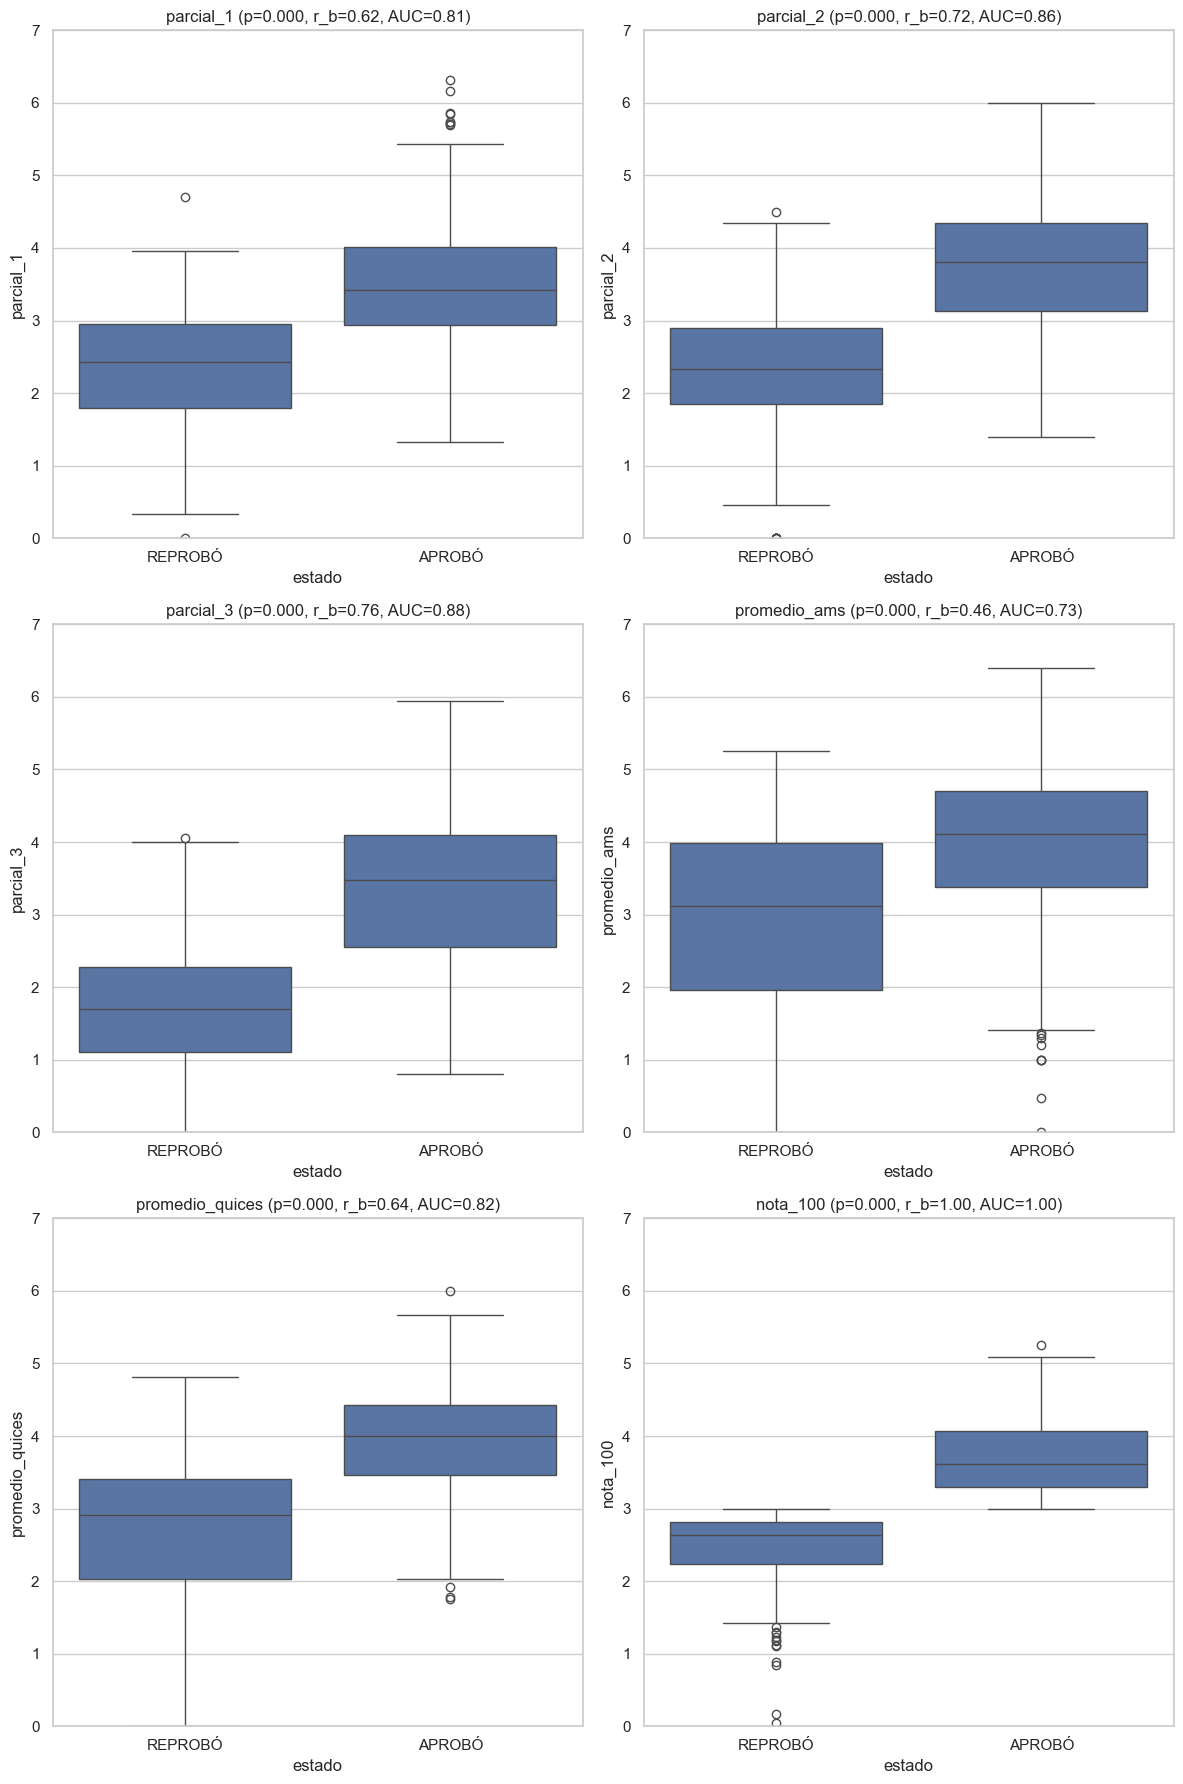

In [22]:
# Crear grilla de boxplots
fig, axes = plt.subplots(3, 2, figsize=(12, 18))
axes = axes.flatten()

for i, var in enumerate(vars_acad):
    sns.boxplot(x='estado', y=var, data=df_activos, ax=axes[i])
    axes[i].set_ylim(0, 7)
    res = df_results_acad[df_results_acad['var'] == var].iloc[0]
    axes[i].set_title(f'{var} (p={res["p_val"]:.3f}, r_b={res["r_b"]:.2f}, AUC={res["AUC"]:.2f})')

plt.tight_layout()
plt.show()

## 5.2.3 Análisis estratificado por era
Repetir los tests Mann-Whitney U separados para formato_antiguo y formato_nuevo. El objetivo es verificar si los efectos son estables entre eras o si alguna variable pierde poder en el nuevo formato. Esto es crítico porque el modelo se aplicará en el formato nuevo.
Visualización: tabla comparativa de r_b y AUC por era. Identificar variables cuyo AUC cae más de 0.05 al cambiar de era.

In [23]:
# Función adaptada para estratificación por era
def calc_signif_by_era(var, df):
    df_antiguo = df[df['era'] == 'formato_antiguo']
    df_nuevo = df[df['era'] == 'formato_nuevo']
    
    res_antiguo = calc_signif_acad(var, df_antiguo)
    res_nuevo = calc_signif_acad(var, df_nuevo)
    
    return {
        'var': var,
        'r_b_antiguo': res_antiguo['r_b'],
        'AUC_antiguo': res_antiguo['AUC'],
        'r_b_nuevo': res_nuevo['r_b'],
        'AUC_nuevo': res_nuevo['AUC'],
        'delta_AUC': res_nuevo['AUC'] - res_antiguo['AUC']
    }

# Aplicar
results_era = [calc_signif_by_era(v, df_activos) for v in vars_acad]

# Tabla comparativa
df_results_era = pd.DataFrame(results_era)
print(df_results_era)

# Identificar caídas >0.05
print("\nVariables con caída AUC >0.05 en formato nuevo:\n", df_results_era[df_results_era['delta_AUC'] < -0.05])

               var  r_b_antiguo  AUC_antiguo  r_b_nuevo  AUC_nuevo  \
0        parcial_1     0.737407     0.868704   0.562664   0.781332   
1        parcial_2     0.850477     0.925239   0.800131   0.900066   
2        parcial_3     0.861214     0.930607   0.689607   0.844803   
3     promedio_ams     0.472959     0.736479   0.461659   0.730830   
4  promedio_quices          NaN          NaN   0.641921   0.820961   
5         nota_100     1.000000     1.000000   1.000000   1.000000   

      delta_AUC  
0 -8.737173e-02  
1 -2.517310e-02  
2 -8.580361e-02  
3 -5.649627e-03  
4           NaN  
5  1.110223e-16  

Variables con caída AUC >0.05 en formato nuevo:
          var  r_b_antiguo  AUC_antiguo  r_b_nuevo  AUC_nuevo  delta_AUC
0  parcial_1     0.737407     0.868704   0.562664   0.781332  -0.087372
2  parcial_3     0.861214     0.930607   0.689607   0.844803  -0.085804


# Sección 5.3 — Significancia de Variables de Engagement
Los hallazgos del NB03 ya reportaron p-valores y medianas para las variables de engagement. Esta sección profundiza en los tamaños de efecto y la contribución marginal del engagement cuando las notas ya están presentes en el modelo.
## 5.3.1 Ranking de engagement por poder discriminante
Tabla ordenada por AUC descendiente. Variables de CP1 disponibles: engagement_hasta_p1, parcial_1_modulos_unicos, parcial_1_temas_unicos, parcial_1_visitas, parcial_1_visitas_por_tema, parcial_1_tiempo_por_visita.
Para cada variable: Mann-Whitney U (p-val), rank-biserial r_b, AUC, interpretación del efecto.

In [24]:
# Variables de engagement en CP1
vars_eng_cp1 = [
    'engagement_hasta_p1', 'parcial_1_modulos_unicos', 'parcial_1_temas_unicos',
    'parcial_1_visitas', 'parcial_1_visitas_por_tema', 'parcial_1_tiempo_por_visita'
]

# Calcular métricas (similar a académicas, usando df_activos_engagement)
results_eng = [calc_signif_acad(v, df_activos_engagement) for v in vars_eng_cp1]  # Reusa la función, ajusta grupos a _eng

# DataFrame y ordenar por AUC descendente
df_results_eng = pd.DataFrame(results_eng).sort_values('AUC', ascending=False)
print(df_results_eng)

# Interpretación del efecto (basado en r_b)
def interpret_eff(r_b):
    abs_r = abs(r_b)
    if abs_r < 0.1: return 'Trivial'
    elif abs_r < 0.3: return 'Pequeño'
    elif abs_r < 0.5: return 'Mediano'
    else: return 'Grande'

df_results_eng['interpretacion'] = df_results_eng['r_b'].apply(interpret_eff)
print(df_results_eng)

                           var  mediana_aprob  mediana_reprob        U  \
0          engagement_hasta_p1       8.274444        5.706389  28962.5   
1     parcial_1_modulos_unicos       7.000000        6.000000  28934.5   
3            parcial_1_visitas      37.000000       32.000000  27664.5   
2       parcial_1_temas_unicos      12.000000       11.000000  27284.5   
4   parcial_1_visitas_por_tema       3.200000        2.833333  27188.0   
5  parcial_1_tiempo_por_visita      12.260000       11.071131  27054.5   

      p_val       r_b       AUC  cohens_d  
0  0.000277  0.203836  0.601918  0.281389  
1  0.000271  0.202673  0.601336  0.368441  
3  0.005558  0.149885  0.574942  0.219839  
2  0.011445  0.134090  0.567045  0.251492  
4  0.013782  0.130079  0.565039  0.078496  
5  0.017462  0.124530  0.562265  0.171147  
                           var  mediana_aprob  mediana_reprob        U  \
0          engagement_hasta_p1       8.274444        5.706389  28962.5   
1     parcial_1_modulos_u

## 5.3.2 Contribución marginal del engagement (análisis de correlación parcial)
Pregunta clave: ¿el engagement agrega información predictiva más allá de parcial_1?
Método: correlación parcial de Spearman entre engagement_hasta_p1 y nota_100, controlando por parcial_1. Si la correlación parcial es significativa (p<0.05), el engagement tiene valor incremental.

In [25]:
# Correlación parcial: engagement → nota_100, controlando por parcial_1
partial_corr = pg.partial_corr(
    data=df_activos_engagement,
    x='engagement_hasta_p1', y='nota_100',
    covar='parcial_1', method='spearman'
)
print(partial_corr)

# Interpretación
if partial_corr['p-val'].values[0] < 0.05:
    print("El engagement tiene valor incremental significativo más allá de parcial_1.")
else:
    print("No hay valor incremental significativo.")

            n        r         CI95%     p-val
spearman  502  0.16609  [0.08, 0.25]  0.000188
El engagement tiene valor incremental significativo más allá de parcial_1.


## 5.3.3 Exclusión justificada de variables de actividades en plataforma
Confirmar con test formal que actividades_n_realizadas, actividades_tiempo_total y actividades_visitas_total no discriminan entre grupos (p>0.05, AUC ≈ 0.5). Incluir tabla con los tres tests. Justificación para su exclusión en los modelos CP1/CP2.

In [26]:
# Variables a excluir
vars_exclude = ['actividades_n_realizadas', 'actividades_tiempo_total', 'actividades_visitas_total']

# Calcular métricas
results_exclude = [calc_signif_acad(v, df_activos_engagement) for v in vars_exclude]

# Tabla
df_results_exclude = pd.DataFrame(results_exclude)
print(df_results_exclude)

# Justificación
print("\nJustificación de exclusión: Estas variables tienen p>0.05 y AUC~0.5, no discriminan. Excluir de modelos para evitar ruido.")

                         var  mediana_aprob  mediana_reprob        U  \
0   actividades_n_realizadas       1.000000        1.000000  22749.5   
1   actividades_tiempo_total       1.149444        1.098333  23945.0   
2  actividades_visitas_total       9.000000       11.000000  22358.0   

      p_val       r_b       AUC  cohens_d  
0  0.829701 -0.054409  0.472795 -0.098711  
1  0.532257 -0.004718  0.497641  0.051965  
2  0.886305 -0.070682  0.464659 -0.145972  

Justificación de exclusión: Estas variables tienen p>0.05 y AUC~0.5, no discriminan. Excluir de modelos para evitar ruido.


# Sección 5.4 — Análisis de Varianza Entre Semestres
El objetivo es verificar si existe varianza sistemática entre semestres que deba ser controlada en los modelos (como variable de era o semestre encoded).
## 5.4.1 Kruskal-Wallis: nota_100 y parcial_1 entre semestres
Test de Kruskal-Wallis sobre nota_100 y parcial_1 con los 5 semestres. Si el test es significativo, tests post-hoc de Dunn con corrección de Bonferroni para identificar qué pares difieren.
Reporte: estadístico H, p-valor, eta-cuadrado (η²). Visualización: boxplots de nota_100 por semestre con anotaciones post-hoc.

nota_100: H=40.08, p=0.000, η²=0.066
   Contrast       A       B  Paired  Parametric    U-val alternative  \
0  semestre  202320  202410   False       False   6036.0   two-sided   
1  semestre  202320  202420   False       False  10110.5   two-sided   
2  semestre  202320  202510   False       False  11938.0   two-sided   
3  semestre  202320  202520   False       False   6588.0   two-sided   
4  semestre  202410  202420   False       False   5638.0   two-sided   
5  semestre  202410  202510   False       False   6704.5   two-sided   
6  semestre  202410  202520   False       False   3666.0   two-sided   
7  semestre  202420  202510   False       False   9063.5   two-sided   
8  semestre  202420  202520   False       False   4874.5   two-sided   
9  semestre  202510  202520   False       False   3438.0   two-sided   

          p-unc        p-corr p-adjust    hedges  
0  7.135514e-01  1.000000e+00     bonf  0.055661  
1  3.547416e-02  3.547416e-01     bonf  0.250273  
2  3.189115e-09  

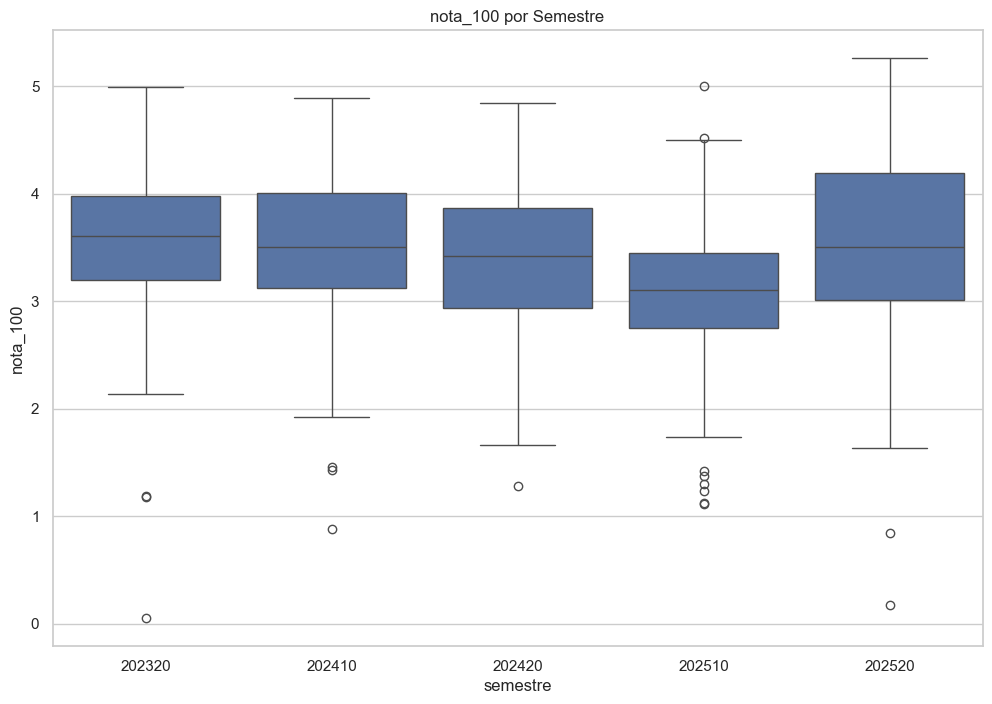

parcial_1: H=10.30, p=0.036, η²=0.011
   Contrast       A       B  Paired  Parametric    U-val alternative  \
0  semestre  202320  202410   False       False   6256.5   two-sided   
1  semestre  202320  202420   False       False  10197.5   two-sided   
2  semestre  202320  202510   False       False   8544.0   two-sided   
3  semestre  202320  202520   False       False   7519.0   two-sided   
4  semestre  202410  202420   False       False   5555.0   two-sided   
5  semestre  202410  202510   False       False   4539.0   two-sided   
6  semestre  202410  202520   False       False   4101.5   two-sided   
7  semestre  202420  202510   False       False   6051.5   two-sided   
8  semestre  202420  202520   False       False   5580.0   two-sided   
9  semestre  202510  202520   False       False   6189.5   two-sided   

      p-unc    p-corr p-adjust    hedges  
0  0.402979  1.000000     bonf  0.170178  
1  0.024963  0.249633     bonf  0.333950  
2  0.767926  1.000000     bonf  0.127436

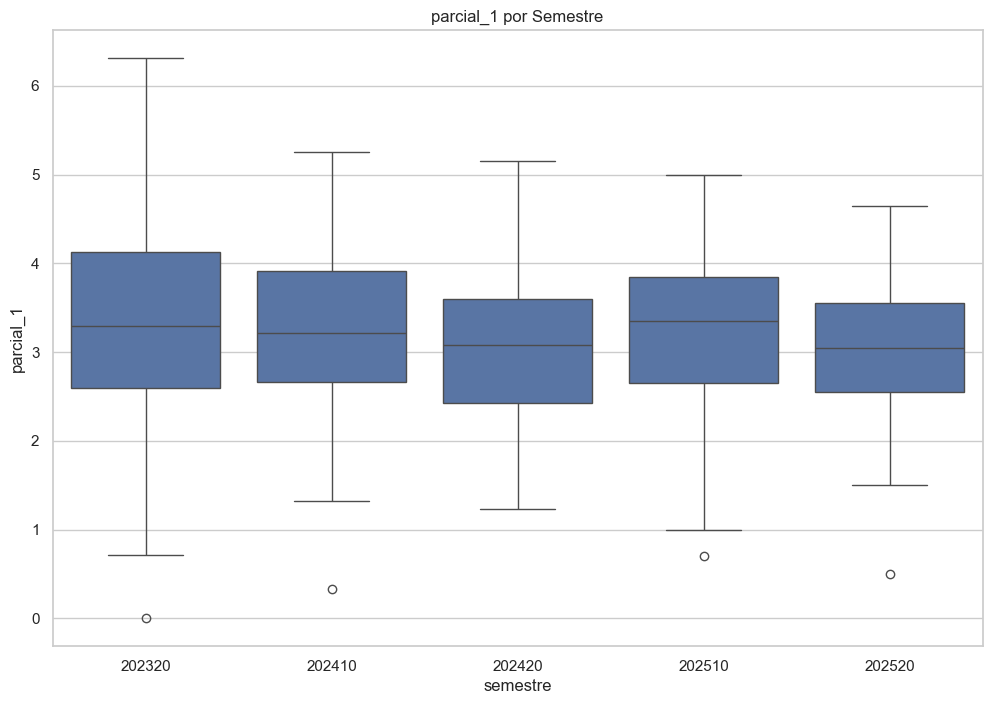

In [27]:
# Variables para Kruskal
vars_kruskal = ['nota_100', 'parcial_1']

for var in vars_kruskal:
    groups = [df_activos[df_activos['semestre'] == s][var].dropna() for s in df_activos['semestre'].unique()]
    H, p_val = kruskal(*groups)
    
    # Eta-cuadrado (aproximado)
    n_total = sum(len(g) for g in groups)
    eta2 = (H - len(groups) + 1) / (n_total - len(groups))
    
    print(f"{var}: H={H:.2f}, p={p_val:.3f}, η²={eta2:.3f}")
    
    if p_val < 0.05:
        # Post-hoc Dunn
        posthoc = pg.pairwise_tests(dv=var, between='semestre', data=df_activos, padjust='bonf', parametric=False)
        print(posthoc)
    
    # Visualización
    sns.boxplot(x='semestre', y=var, data=df_activos)
    plt.title(f'{var} por Semestre')
    plt.show()

## 5.4.2 Eta-cuadrado: varianza explicada por era vs. semestre
Comparar cuánta varianza en nota_100 explica la era (antiguo vs. nuevo) vs. el semestre específico. Si η²_era > η²_semestre, basta con incluir era como variable de control. Si η²_semestre es grande, considerar encoding del semestre o variables de tendencia temporal.

In [28]:
# Para era
groups_era = [df_activos[df_activos['era_encoded'] == i]['nota_100'].dropna() for i in [0,1]]
H_era, p_era = kruskal(*groups_era)
n_era = sum(len(g) for g in groups_era)
eta2_era = (H_era - 2 + 1) / (n_era - 2)

# Para semestre (de arriba)
eta2_sem = eta2  # Del loop anterior para nota_100

print(f"η²_era={eta2_era:.3f}, η²_semestre={eta2_sem:.3f}")

if eta2_era > eta2_sem:
    print("Basta con era como control.")
else:
    print("Considerar encoding de semestre.")

η²_era=0.029, η²_semestre=0.011
Basta con era como control.


## 5.4.3 Modalidad grupal vs. individual en AMs
Análisis focalizado en formato nuevo: comparar am_1, am_2, am_3 entre 202420 (grupal) y 202510+202520 (individual).
Reporte: Mann-Whitney U, r_b, AUC de cada AM como predictor de nota_100 según modalidad. Respuesta esperada: modalidad grupal puede inflar medias de AM pero no altera significativamente el poder predictivo. Incluir variable 'modalidad_am' como feature de control en CP1 del formato nuevo.
Python

In [29]:
# Filtrar formato nuevo
df_nuevo = df_activos[df_activos['era'] == 'formato_nuevo']

# Crear modalidad_am: 1=grupal (202420), 0=individual (otros)
df_nuevo['modalidad_am'] = (df_nuevo['semestre'] == 202420).astype(int)

# Variables AM
vars_am = ['am_1', 'am_2', 'am_3']

# Función para AUC por modalidad
def auc_by_mod(var, df, mod_col='modalidad_am'):
    df_grup = df[df[mod_col] == 1][[var, 'estado_binario']].dropna()
    df_ind = df[df[mod_col] == 0][[var, 'estado_binario']].dropna()
    
    auc_grup = roc_auc_score(df_grup['estado_binario'], df_grup[var]) if len(df_grup) > 0 else np.nan
    auc_ind = roc_auc_score(df_ind['estado_binario'], df_ind[var]) if len(df_ind) > 0 else np.nan
    
    # Mann-Whitney entre modalidades
    grup_vals = df[df[mod_col] == 1][var].dropna()
    ind_vals = df[df[mod_col] == 0][var].dropna()
    res_mw = pg.mwu(grup_vals, ind_vals)
    
    return {
        'var': var,
        'mediana_grup': grup_vals.median(),
        'mediana_ind': ind_vals.median(),
        'r_b_mw': res_mw['RBC'].values[0],
        'p_val_mw': res_mw['p-val'].values[0],
        'AUC_grup': auc_grup,
        'AUC_ind': auc_ind
    }

results_am_mod = [auc_by_mod(v, df_nuevo) for v in vars_am]

df_results_am_mod = pd.DataFrame(results_am_mod)
print(df_results_am_mod)

print("\nRecomendación: Incluir 'modalidad_am' como control si diferencias son significativas.")

    var  mediana_grup  mediana_ind    r_b_mw      p_val_mw  AUC_grup   AUC_ind
0  am_1          3.75         3.85  0.040019  5.438491e-01  0.347138  0.348867
1  am_2          4.13         3.65  0.174284  8.171730e-03  0.319192  0.365242
2  am_3          4.06         3.06  0.399045  1.390832e-09  0.369360  0.246430

Recomendación: Incluir 'modalidad_am' como control si diferencias son significativas.


C:\Users\nicot\AppData\Local\Temp\ipykernel_37480\4100778638.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nuevo['modalidad_am'] = (df_nuevo['semestre'] == 202420).astype(int)


# Sección 5.5 — Análisis de Multicolinealidad
Antes de construir los feature sets para CP1 y CP2, es necesario identificar variables redundantes que puedan desestabilizar los modelos lineales y aumentar el ruido en modelos de árbol.
## 5.5.1 Matriz de correlación de Spearman (feature set CP1)
Heatmap de correlación de Spearman entre todas las variables del CP1: parcial_1, am_1, am_2 (si disponibles), quiz_1 (si disponible), engagement_hasta_p1, parcial_1_modulos_unicos, parcial_1_visitas_por_tema, parcial_1_tiempo_por_visita. Subconjunto: df_activos_engagement, formato_nuevo.
Identificar pares con |r| > 0.85 para exclusión o combinación en el feature set final.

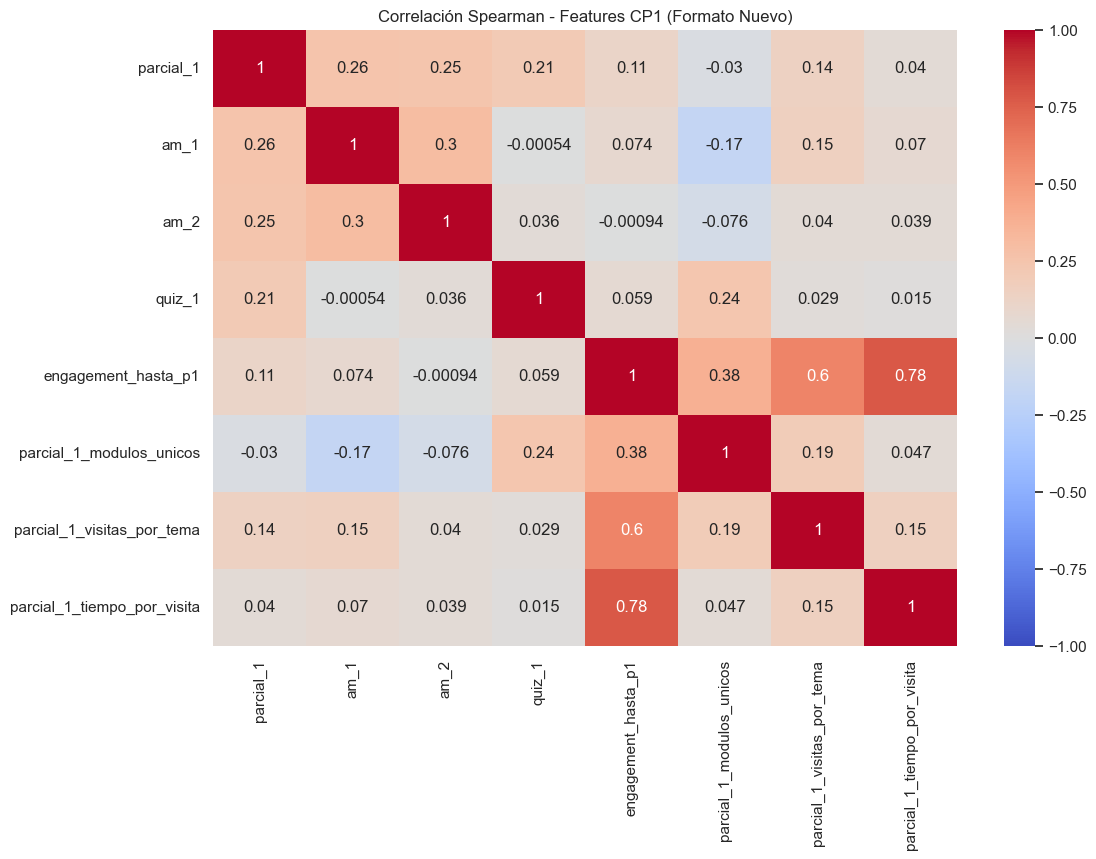

Pares con |r| > 0.85: []


In [30]:
# Features CP1 (ajustar si quiz_1 no siempre disponible)
features_cp1 = ['parcial_1', 'am_1', 'am_2', 'quiz_1', 'engagement_hasta_p1',
                'parcial_1_modulos_unicos', 'parcial_1_visitas_por_tema', 'parcial_1_tiempo_por_visita']

# Filtrar formato nuevo
df_cp1_nuevo = df_activos_engagement[df_activos_engagement['era'] == 'formato_nuevo'][features_cp1].dropna(axis=1, how='all')  # Drop cols all NaN

# Matriz Spearman
corr_spear = df_cp1_nuevo.corr(method='spearman')

# Heatmap
sns.heatmap(corr_spear, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación Spearman - Features CP1 (Formato Nuevo)')
plt.show()

# Identificar pares >0.85
high_corr = [(i,j) for i in corr_spear for j in corr_spear if i != j and abs(corr_spear.loc[i,j]) > 0.85]
print("Pares con |r| > 0.85:", high_corr)

## 5.5.2 Varianza Inflation Factor (VIF) para features de regresión
Calcular VIF para el feature set CP1 y CP2 planificado. Features con VIF > 10 indican alta multicolinealidad — se excluye el de menor AUC individual del par redundante.

In [31]:
# Preparar X para VIF (imputar NaNs con 0, como en reglas)
X_cp1 = df_cp1_nuevo.fillna(0)

# Calcular VIF
vif_data = pd.DataFrame()
vif_data['feature'] = X_cp1.columns
vif_data['VIF'] = [variance_inflation_factor(X_cp1.values, i) for i in range(X_cp1.shape[1])]

print(vif_data.sort_values('VIF', ascending=False))

print("\nRecomendación: Excluir features con VIF>10, priorizando las de menor AUC.")

                       feature        VIF
0                    parcial_1  13.683526
2                         am_2  10.418131
1                         am_1   9.433469
5     parcial_1_modulos_unicos   7.204513
6   parcial_1_visitas_por_tema   5.396519
3                       quiz_1   5.199993
4          engagement_hasta_p1   3.985317
7  parcial_1_tiempo_por_visita   3.846269

Recomendación: Excluir features con VIF>10, priorizando las de menor AUC.


# Sección 5.6 — Feature Importance Preliminar vía Random Forest
Un Random Forest entrenado con todas las features disponibles al final del semestre provee un ranking de importancia empírico que complementa los análisis estadísticos.
## 5.6.1 Configuración del modelo base
Subconjunto: df_activos_engagement (N=502). Target: estado_binario (REPROBÓ=1). Features: todas las variables numéricas disponibles al CP3. Sin optimización de hiperparámetros — es un análisis de importancia, no el modelo final.

In [32]:
# Features al CP3 (todas numéricas relevantes, excluyendo targets y categóricas)
features_cp3 = [col for col in df_activos_engagement.columns if col not in ['estado', 'estado_binario', 'semestre', 'era', 'id_estudiante'] and pd.api.types.is_numeric_dtype(df_activos_engagement[col])]

X = df_activos_engagement[features_cp3].fillna(0)  # Imputar 0
y = df_activos_engagement['estado_binario']

# Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
rf = RandomForestClassifier(n_estimators=500, max_depth=8, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# MDI importance
mdi_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Permutation importance
perm = permutation_importance(rf, X_val, y_val, n_repeats=20, random_state=42)
perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
perm_std = pd.Series(perm.importances_std, index=X.columns)

## 5.6.2 Visualización y comparación con análisis estadístico
Gráfico de barras horizontales con Permutation Importance (media ± std) para el top-20 de features. Tabla comparativa: variable | Spearman r | p-value MW | Cohen's d | AUC indiv. | RF Perm. Importance | disponible en CP1/CP2.

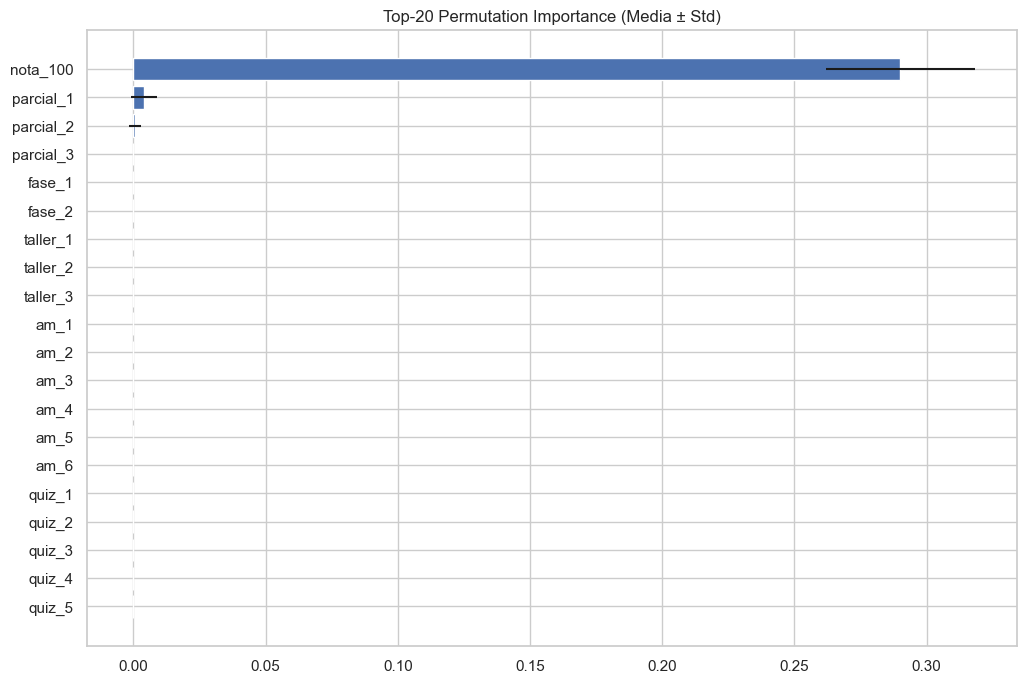

                            var       r_b         p_val  cohens_d       AUC  \
0                     parcial_1  0.620387  1.770527e-28  1.242444  0.810194   
1                     parcial_2  0.722374  6.649601e-38  1.559165  0.861187   
2                     parcial_3  0.762987  4.727840e-42  1.661280  0.881493   
3                  promedio_ams  0.456150  2.906820e-16  0.914427  0.728075   
4               promedio_quices  0.641921  1.007889e-20  1.363411  0.820961   
5                      nota_100  1.000000  9.971112e-71  2.412387  1.000000   
6           engagement_hasta_p1  0.203836  2.774645e-04  0.281389  0.601918   
7      parcial_1_modulos_unicos  0.202673  2.713407e-04  0.368441  0.601336   
8             parcial_1_visitas  0.149885  5.557789e-03  0.219839  0.574942   
9        parcial_1_temas_unicos  0.134090  1.144500e-02  0.251492  0.567045   
10   parcial_1_visitas_por_tema  0.130079  1.378162e-02  0.078496  0.565039   
11  parcial_1_tiempo_por_visita  0.124530  1.746179e

In [33]:
# Gráfico top-20 permutation
top20 = perm_imp.head(20)
plt.barh(top20.index[::-1], top20.values[::-1], xerr=perm_std[top20.index][::-1])
plt.title('Top-20 Permutation Importance (Media ± Std)')
plt.show()

# Tabla comparativa (combinar con results_acad y results_eng)
all_results = pd.concat([df_results_acad, df_results_eng], ignore_index=True)
all_results['RF_Perm_Imp'] = all_results['var'].map(perm_imp)
all_results['disponible_CP1'] = all_results['var'].isin(features_cp1 + ['era_encoded'])  # Ajustar
all_results['disponible_CP2'] = True  # La mayoría en CP2

print(all_results[['var', 'r_b', 'p_val', 'cohens_d', 'AUC', 'RF_Perm_Imp', 'disponible_CP1', 'disponible_CP2']])

# Sección 5.7 — Tabla Maestra de Features
Este es el ENTREGABLE central del Notebook 05. Consolida todos los análisis anteriores en una tabla de referencia que guía directamente la construcción de los feature sets en NB06.
Estructura de la Tabla Maestra: Variable | Tipo | AUC | r_b (MW) | p-val | Cohen's d | RF Imp. | CP1 | CP2 | Recomendación
*Nota: engagement_hasta_p1 y parcial_1_tiempo_hrs son la misma variable (r=1.0). Usar solo engagement_hasta_p1.
REGLAS DE INCLUSIÓN/EXCLUSIÓN DERIVADAS DE LA TABLA MAESTRA:

INCLUIR siempre en CP1: parcial_1, engagement_hasta_p1, parcial_1_modulos_unicos, era_encoded
INCLUIR si disponibles en CP1: am_1, am_2, quiz_1 (según semestre activo)
INCLUIR siempre en CP2: todo CP1 + parcial_2, engagement_hasta_p2, am adicionales, quices adicionales
FEATURES DERIVADAS a crear en NB06: tendencia_p2_p1, tendencia_eng_p2_p1, ratio_eng_notas
EXCLUIR siempre: actividades_n_realizadas, actividades_tiempo_total, actividades_visitas_total, parcial_1_tiempo_hrs (colineal con engagement_hasta_p1)


In [35]:
# Construir Tabla Maestra (usando all_results y exclusiones)
# Construir Tabla Maestra (usando all_results y exclusiones)
tabla_maestra = all_results.copy()

# Asignar Tipo de manera más precisa
tabla_maestra['Tipo'] = 'Académica'  # Default para académicas
engagement_vars = ['engagement_hasta_p1', 'parcial_1_modulos_unicos', 'parcial_1_temas_unicos', 
                   'parcial_1_visitas', 'parcial_1_visitas_por_tema', 'parcial_1_tiempo_por_visita',
                   'actividades_n_realizadas', 'actividades_tiempo_total', 'actividades_visitas_total']
tabla_maestra.loc[tabla_maestra['var'].isin(engagement_vars), 'Tipo'] = 'Engagement'

# Manejar nota_100 como target (no feature)
if 'nota_100' in tabla_maestra['var'].values:
    tabla_maestra.loc[tabla_maestra['var'] == 'nota_100', 'Tipo'] = 'Target (Validación)'
    tabla_maestra.loc[tabla_maestra['var'] == 'nota_100', 'CP1'] = '✗'
    tabla_maestra.loc[tabla_maestra['var'] == 'nota_100', 'CP2'] = '✗'
    tabla_maestra.loc[tabla_maestra['var'] == 'nota_100', 'Recomendación'] = 'EXCLUIR (Target)'

tabla_maestra['CP1'] = tabla_maestra['disponible_CP1'].map({True: '✓', False: '✗'})
tabla_maestra['CP2'] = tabla_maestra['disponible_CP2'].map({True: '✓', False: '✗'})
tabla_maestra['Recomendación'] = 'INCLUIR'  # Default, ajustar manualmente basados en VIF y corr

# ... (el resto del código para agregar era_encoded y exclusiones queda igual)
tabla_maestra['CP1'] = tabla_maestra['disponible_CP1'].map({True: '✓', False: '✗'})
tabla_maestra['CP2'] = tabla_maestra['disponible_CP2'].map({True: '✓', False: '✗'})
tabla_maestra['Recomendación'] = 'INCLUIR'  # Default, ajustar manualmente basados en VIF y corr

# Agregar era_encoded (no en results, agregar manual)
era_row = {'var': 'era_encoded', 'Tipo': 'Control', 'AUC': np.nan, 'r_b': np.nan, 'p_val': np.nan, 
           'cohens_d': np.nan, 'RF_Perm_Imp': perm_imp.get('era_encoded', np.nan), 'CP1': '✓', 'CP2': '✓', 'Recomendación': 'INCLUIR como control'}
tabla_maestra = pd.concat([tabla_maestra, pd.DataFrame([era_row])], ignore_index=True)

# Agregar exclusiones
for v in vars_exclude:
    ex_row = df_results_exclude[df_results_exclude['var'] == v].iloc[0]
    ex_dict = {'var': v, 'Tipo': 'Engagement', 'AUC': ex_row['AUC'], 'r_b': ex_row['r_b'], 'p_val': ex_row['p_val'],
               'cohens_d': ex_row['cohens_d'], 'RF_Perm_Imp': perm_imp.get(v, np.nan), 'CP1': '✗', 'CP2': '✗', 'Recomendación': 'EXCLUIR'}
    tabla_maestra = pd.concat([tabla_maestra, pd.DataFrame([ex_dict])], ignore_index=True)

# Ordenar y mostrar
tabla_maestra = tabla_maestra[['var', 'Tipo', 'AUC', 'r_b', 'p_val', 'cohens_d', 'RF_Perm_Imp', 'CP1', 'CP2', 'Recomendación']]
print(tabla_maestra)

# Guardar como CSV para NB06
tabla_maestra.to_csv('tabla_maestra_features.csv', index=False)

                            var                 Tipo       AUC       r_b  \
0                     parcial_1            Académica  0.810194  0.620387   
1                     parcial_2            Académica  0.861187  0.722374   
2                     parcial_3            Académica  0.881493  0.762987   
3                  promedio_ams            Académica  0.728075  0.456150   
4               promedio_quices            Académica  0.820961  0.641921   
5                      nota_100  Target (Validación)  1.000000  1.000000   
6           engagement_hasta_p1           Engagement  0.601918  0.203836   
7      parcial_1_modulos_unicos           Engagement  0.601336  0.202673   
8             parcial_1_visitas           Engagement  0.574942  0.149885   
9        parcial_1_temas_unicos           Engagement  0.567045  0.134090   
10   parcial_1_visitas_por_tema           Engagement  0.565039  0.130079   
11  parcial_1_tiempo_por_visita           Engagement  0.562265  0.124530   
12          